# SHAP execution

**Purpose:** Train an XGBoost classifier to predict which DTW
trajectory cluster each economy belongs to, using
only structural features measured at 1971 (Matrix B).
Apply TreeSHAP to quantify each feature's contribution.

### Intent:
Gate: silhouette score from Day 3 MUST be >= 0.3 before running.
Low silhouette => noisy cluster labels => SHAP explains noise.

**Source**:
1. Chen & Guestrin (2016) -- XGBoost, KDD pp. 785-794
2. Lundberg & Lee (2017) -- SHAP, NeurIPS pp. 4765-4774
3. Molnar (2025) -- Interpretable ML, Ch. 9
4. Celik & Koroglu (2026) -- Random forest + SHAP on gender inequality
5. Hyland, Djankov & Goldberg (2020) -- AER: Insights 2(4), 475-490
6. Al-Marhubi (2026) -- convergence drivers, Section 2.2





In [ ]:
# Install this package
!pip install xgboost shap scikit-learn -q
print("Installed. If this is a fresh session, no restart needed -- these are pure Python.")


Installed. If this is a fresh session, no restart needed -- these are pure Python.


In [ ]:
# change this path to yours
BASE = '/content/drive/MyDrive/wbl_project'

In [ ]:
# uncomment if you are using Google Drive
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
import shap
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score,
                             ConfusionMatrixDisplay, accuracy_score)
from sklearn.dummy import DummyClassifier
import sklearn
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.image as mpimg


os.makedirs(f'{BASE}/outputs/figures', exist_ok=True)
os.makedirs(f'{BASE}/models',          exist_ok=True)

print(f"XGBoost version : {xgb.__version__}")
print(f"SHAP version    : {shap.__version__}")

Mounted at /content/drive
XGBoost version : 3.2.0
SHAP version    : 0.51.0
BASE            : /content/drive/MyDrive/wbl_project
Exists          : True


In [ ]:
# Load and merge Matrix B + cluster labels
# Anti-leakage rule (DD-000a): cluster_labels.csv was produced
# exclusively from Matrix A (WBL scores). wbl_features.csv was
# produced exclusively from external sources. They share only the
# economy ISO3 index. No WBL sub-index is present in Matrix B.

features_path = f'{BASE}/data/processed/wbl_features.csv'
labels_path   = f'{BASE}/data/processed/cluster_labels.csv'

for p in [features_path, labels_path]:
    assert os.path.exists(p), f"MISSING: {p}"

features = pd.read_csv(features_path, index_col=0)
labels   = pd.read_csv(labels_path,   index_col=0)

# Merge on economy index
df = features.join(labels, how='inner')

print(f"Matrix B shape : {features.shape}")
print(f"Labels shape : {labels.shape}")
print(f"Merged shape : {df.shape}")
print(f"\nColumns in Matrix B:")
for col in features.columns:
    print(f"  {col}")

assert len(df) == 189, f"Expected 189 rows, got {len(df)}"
assert 'cluster' in df.columns, "cluster column missing -- check cluster_labels.csv"

# Anti-leakage check: confirm no WBL sub-index column is present
wbl_subindex_keywords = ['mobility','workplace','pay','marriage',
                          'parenthood','entrepreneur','asset','pension','wbl']
leakage_cols = [c for c in features.columns
                if any(k in c.lower() for k in wbl_subindex_keywords)]
if leakage_cols:
    raise ValueError(f"LEAKAGE DETECTED -- WBL sub-index columns in Matrix B: {leakage_cols}")
print("\nAnti-leakage check PASSED -- no WBL sub-index columns in Matrix B.")


Matrix B shape  : (189, 12)
Labels shape    : (189, 1)
Merged shape    : (189, 13)

Columns in Matrix B:
  gdp_pc_log
  flfp
  trade_openness
  income_group
  region_EAS
  region_ECS
  region_LCN
  region_MEA
  region_NAC
  region_SAS
  region_SSF
  democracy

Anti-leakage check PASSED -- no WBL sub-index columns in Matrix B.


In [ ]:
# Prepare features and target
#
# XGBoost handles:
#   - Continuous features: gdp_pc_log, flfp, trade_openness, democracy
#   - Ordinal feature:     income_group (1-4, already encoded)
#   - Binary dummies:      region_* columns (already one-hot encoded)
#   - Missing values:      natively via sparsity-aware split-finding
#                          (Chen & Guestrin 2016, p.4)
#
# Class imbalance: if one cluster dominates (>60% of total),
# we use sample_weight to give minority clusters more influence.
# This ensures macro-F1 is meaningful, not just accuracy on the
# dominant class. Reference: project methodology document Section 5.

# Separate features from target
# Target: cluster labels (already 1-indexed from Day 3)
y = df['cluster'].values - 1   # convert to 0-indexed for XGBoost
X = df.drop(columns=['cluster'])

# Store feature names for SHAP plots
FEATURE_NAMES = X.columns.tolist()
ECONOMIES     = df.index.tolist()
N_CLASSES     = len(np.unique(y))

print(f"Feature matrix: {X.shape} ({X.shape[1]} features)")
print(f"Target vector : {y.shape} ({N_CLASSES} classes)")
print(f"CLASS DISTRIBUTION")
for c in sorted(np.unique(y)):
    n   = (y == c).sum()
    pct = 100 * n / len(y)
    print(f"  Cluster {c+1}: {n:3d} economies  ({pct:.1f}%)")

# Compute class weights for imbalanced case
sample_weights = compute_sample_weight(class_weight='balanced', y=y)

# Flag severe imbalance (any class < 10% of total)
min_class_pct = min((y == c).sum() / len(y) for c in np.unique(y)) * 100
if min_class_pct < 10:
    print(f"\nWARNING: Severe class imbalance (smallest class = {min_class_pct:.1f}%).")
    print("  sample_weight='balanced' applied to all XGBoost fits.")
    USE_WEIGHTS = True
else:
    print(f"\nClass balance acceptable (smallest class = {min_class_pct:.1f}%).")
    USE_WEIGHTS = False


Feature matrix  : (189, 12)  (12 features)
Target vector   : (189,)  (3 classes)

=== CLASS DISTRIBUTION ===
  Cluster 1:  96 economies  (50.8%)
  Cluster 2:  35 economies  (18.5%)
  Cluster 3:  58 economies  (30.7%)

Class balance acceptable (smallest class = 18.5%).

=== MISSING VALUES IN MATRIX B ===
  flfp: 11 missing (5.8%)
  trade_openness: 14 missing (7.4%)
  (XGBoost handles these natively -- no imputation applied, DD-006)


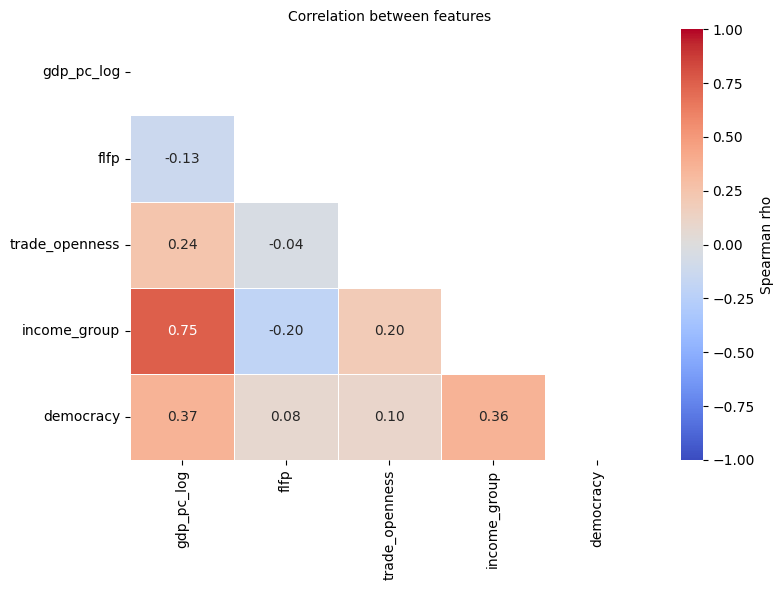

Saved: /content/drive/MyDrive/wbl_project/outputs/figures/feature_correlation.png


In [18]:
# Correlation check
# Use only continuous + ordinal features for correlation check
# (region dummies are binary so Pearson is less meaningful)
cont_cols = [c for c in X.columns if not c.startswith('region_')]
corr = X[cont_cols].corr(method='spearman')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Spearman rho'})
ax.set_title('Correlation between features',
             fontsize=10)
plt.tight_layout()

# save the plot
fig_path = f'{BASE}/outputs/figures/feature_correlation.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


In [ ]:
# Baseline dummy classifier
# We must establish a floor. If XGBoost only barely beats
# 'always predict the majority class', the structural features
# have weak predictive power -- that itself is a result.
# Reference: project methodology document, DD-012.

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X, y)
y_dummy = dummy.predict(X)

dummy_acc  = (y_dummy == y).mean()
dummy_f1   = f1_score(y, y_dummy, average='macro', zero_division=0)

print("=== DUMMY CLASSIFIER (most-frequent baseline) ===")
print(f"  Accuracy  : {dummy_acc:.4f}  ({dummy_acc*100:.1f}%)")
print(f"  Macro-F1  : {dummy_f1:.4f}")
print()
print("XGBoost must meaningfully beat these numbers.")
print("Target: Macro-F1 > 0.70 to proceed to SHAP interpretation.")
print("(Reference: project methodology document, Section 5)")


=== DUMMY CLASSIFIER (most-frequent baseline) ===
  Accuracy  : 0.5079  (50.8%)
  Macro-F1  : 0.2246

XGBoost must meaningfully beat these numbers.
Target: Macro-F1 > 0.70 to proceed to SHAP interpretation.
(Reference: project methodology document, Section 5)


In [ ]:
# Cell 6 -- XGBoost with stratified 5-fold cross-validation
#
# Hyperparameters (conservative for n=189):
#   n_estimators     = 200  : enough trees with slow learning rate
#   max_depth        = 4    : shallow trees to prevent overfitting on 189 obs
#   learning_rate    = 0.05 : slow, relies on many trees
#   subsample        = 0.8  : row subsampling (stochastic gradient boosting)
#   colsample_bytree = 0.8  : column subsampling per tree
#   min_child_weight = 5    : each leaf needs >= 5 economies (key for n=189)
#   reg_alpha        = 0.1  : L1 regularisation
#   reg_lambda       = 1.0  : L2 regularisation (default XGBoost value)

objective   = 'binary:logistic' if N_CLASSES == 2 else 'multi:softprob'
eval_metric = 'logloss'         if N_CLASSES == 2 else 'mlogloss'

model_params = dict(
    n_estimators     = 200,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = objective,
    eval_metric      = eval_metric,
    random_state     = 42,
    n_jobs           = -1,
)

print(f"scikit-learn: {sklearn.__version__}")
print(f"XGBoost     : {xgb.__version__}")

# Manual 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y[train_idx],      y[test_idx]

    # Sample weights for this fold's training set only
    sw_tr = sample_weights[train_idx] if USE_WEIGHTS else None

    model = xgb.XGBClassifier(**model_params)
    model.fit(X_tr, y_tr, sample_weight=sw_tr)

    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    fold_results.append({
        'fold'          : fold,
        'train_accuracy': accuracy_score(y_tr, y_pred_tr),
        'test_accuracy' : accuracy_score(y_te, y_pred_te),
        'train_f1_macro': f1_score(y_tr, y_pred_tr, average='macro', zero_division=0),
        'test_f1_macro' : f1_score(y_te, y_pred_te, average='macro', zero_division=0),
        'train_bal_acc' : balanced_accuracy_score(y_tr, y_pred_tr),
        'test_bal_acc'  : balanced_accuracy_score(y_te, y_pred_te),
    })
    print(f"  Fold {fold}:  test accuracy = {fold_results[-1]['test_accuracy']:.3f}"
          f"  |  test macro-F1 = {fold_results[-1]['test_f1_macro']:.3f}")

cv_df = pd.DataFrame(fold_results)
cv_df.to_csv(f'{BASE}/data/processed/cv_results.csv', index=False)

# Summary table
print()
print("=== 5-FOLD CROSS-VALIDATION RESULTS ===")
print(f"{'Metric':<22} {'Train mean':>12} {'Train std':>10} {'Test mean':>12} {'Test std':>10}")
print("-" * 70)
for col, label in [('accuracy','Accuracy'), ('f1_macro','Macro-F1'), ('bal_acc','Balanced Acc')]:
    tr_m = cv_df[f'train_{col}'].mean()
    tr_s = cv_df[f'train_{col}'].std()
    te_m = cv_df[f'test_{col}'].mean()
    te_s = cv_df[f'test_{col}'].std()
    print(f"{label:<22} {tr_m:>12.4f} {tr_s:>10.4f} {te_m:>12.4f} {te_s:>10.4f}")

cv_macro_f1 = cv_df['test_f1_macro'].mean()
print()
if cv_macro_f1 >= 0.70:
    print(f"Macro-F1 = {cv_macro_f1:.4f} -- THRESHOLD MET (>= 0.70). Proceeding to SHAP.")
    PROCEED_TO_SHAP = True
elif cv_macro_f1 >= 0.50:
    print(f"Macro-F1 = {cv_macro_f1:.4f} -- Below 0.70 but above 0.50.")
    print("Proceed with caution. Disclose limitation in DD-013.")
    PROCEED_TO_SHAP = True
else:
    print(f"Macro-F1 = {cv_macro_f1:.4f} -- BELOW 0.50.")
    print("WARNING: Model barely beats random. Check:")
    print("  1. Silhouette >= 0.3 from Day 3? Low silhouette = noisy labels.")
    print("  2. Cluster sizes severely imbalanced?")
    print("  3. Do the 7 features vary meaningfully across clusters?")
    PROCEED_TO_SHAP = False
    print("Set PROCEED_TO_SHAP = True manually to override and continue.")


scikit-learn: 1.6.1
XGBoost     : 3.2.0

  Fold 1:  test accuracy = 0.711  |  test macro-F1 = 0.691
  Fold 2:  test accuracy = 0.763  |  test macro-F1 = 0.737
  Fold 3:  test accuracy = 0.632  |  test macro-F1 = 0.621
  Fold 4:  test accuracy = 0.763  |  test macro-F1 = 0.720
  Fold 5:  test accuracy = 0.865  |  test macro-F1 = 0.839

=== 5-FOLD CROSS-VALIDATION RESULTS ===
Metric                   Train mean  Train std    Test mean   Test std
----------------------------------------------------------------------
Accuracy                     0.9180     0.0151       0.7467     0.0852
Macro-F1                     0.9059     0.0164       0.7216     0.0790
Balanced Acc                 0.8913     0.0174       0.7134     0.0682

Macro-F1 = 0.7216 -- THRESHOLD MET (>= 0.70). Proceeding to SHAP.


=== FINAL MODEL (fit on full 189 economies) ===
  In-sample accuracy : 0.9259
  In-sample macro-F1 : 0.9146
  (CV macro-F1       : 0.7216  -- this is the generalisation estimate)

              precision    recall  f1-score   support

   Cluster 1       0.91      0.96      0.93        96
   Cluster 2       0.93      0.80      0.86        35
   Cluster 3       0.95      0.95      0.95        58

    accuracy                           0.93       189
   macro avg       0.93      0.90      0.91       189
weighted avg       0.93      0.93      0.92       189



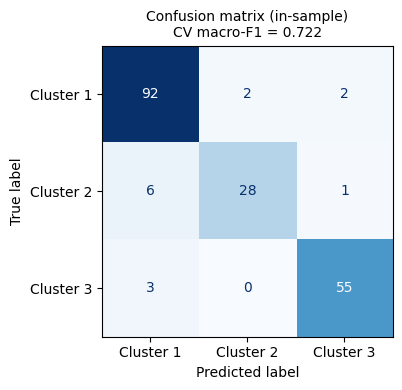

Saved: /content/drive/MyDrive/wbl_project/outputs/figures/confusion_matrix.png
Model saved: /content/drive/MyDrive/wbl_project/models/xgb_cluster_classifier.json


In [ ]:
# Fit on full dataset, evaluate, save
# We fit on the FULL 189 economies (no hold-out) for the SHAP analysis.
# Rationale: with n=189 we cannot afford to withhold 38 economies
# from SHAP. Cross-validation in Cell 6 already established
# out-of-sample performance. The final model is for explanation only.
# Reference: Molnar (2025, Ch. 9): "SHAP is most informative when
# computed on training data that the model has seen."

fit_params_final = {}
if USE_WEIGHTS:
    fit_params_final['sample_weight'] = sample_weights

clf_final = xgb.XGBClassifier(**model_params)
clf_final.fit(X, y, **fit_params_final)

# In-sample performance (expected to be higher than CV -- not the primary metric)
y_pred_train = clf_final.predict(X)
train_f1     = f1_score(y, y_pred_train, average='macro', zero_division=0)
train_acc    = (y_pred_train == y).mean()

print(f"In-sample accuracy : {train_acc:.4f}")
print(f"In-sample macro-F1 : {train_f1:.4f}")
print(f"(CV macro-F1 : {cv_macro_f1:.4f}")

# Classification report
target_names = [f'Cluster {c+1}' for c in range(N_CLASSES)]
print(classification_report(y, y_pred_train, target_names=target_names, zero_division=0))

# Plot Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y, y_pred_train)
disp = ConfusionMatrixDisplay(cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix (in-sample)\nCV macro-F1 = {cv_macro_f1:.3f}', fontsize=10)
plt.tight_layout()
fig_path = f'{BASE}/outputs/figures/confusion_matrix.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

# Save model
model_path = f'{BASE}/models/xgb_cluster_classifier.json'
clf_final.save_model(model_path)
print(f"Model saved: {model_path}")


In [ ]:
#  Compute TreeSHAP values
# TreeSHAP (Lundberg & Lee 2017) computes exact Shapley values
#
# Key property (Local Accuracy, Molnar 2025 Ch. 9):
# f(x_i) = E[f(X)] + sum_j phi_j(i)
# SHAP values sum exactly to model prediction minus baseline.
#
# FIX for TypeError: Cannot cast dtype('O') to dtype('float64'):
# pd.get_dummies() creates bool/object columns for region dummies.
# XGBoost's fit/predict casts internally; the SHAP C extension does not.
# Solution: cast X to float64 before passing to TreeExplainer.

# Cast X to float64
X_float = X.astype(float)
print("Dtypes after float cast:")
print(X_float.dtypes.value_counts().to_string())

# Compute TreeSHAP
print("Computing TreeSHAP values...")
explainer = shap.TreeExplainer(clf_final, data=X_float, feature_perturbation='tree_path_dependent')
shap_values = explainer.shap_values(X_float)

# Normalise output to a list of k matrices (one per cluster)
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = [shap_values[:, :, c] for c in range(N_CLASSES)]
    print(f"Converted 3D array to list of {N_CLASSES} matrices.")
elif isinstance(shap_values, list):
    print(f"SHAP values: list of {len(shap_values)} class matrices.")
else:
    shap_values = [shap_values, -shap_values]
    print("Binary case: complementary matrices created.")

print(f"Each matrix shape: {shap_values[0].shape}  "
      f"({shap_values[0].shape[0]} economies x {len(FEATURE_NAMES)} features)")

# Save SHAP values for all classes
shap_dfs = []
for c, sv in enumerate(shap_values):
    df_sv = pd.DataFrame(sv, index=ECONOMIES, columns=FEATURE_NAMES)
    df_sv.insert(0, 'class', c + 1)
    shap_dfs.append(df_sv)
shap_all = pd.concat(shap_dfs)
shap_path = f'{BASE}/data/processed/shap_values.csv'
shap_all.to_csv(shap_path)
print(f"SHAP values saved: {shap_path}")


Dtypes after float cast:
float64    12

Computing TreeSHAP values...
Converted 3D array to list of 3 matrices.
Each matrix shape: (189, 12)  (189 economies x 12 features)
SHAP values saved: /content/drive/MyDrive/wbl_project/data/processed/shap_values.csv


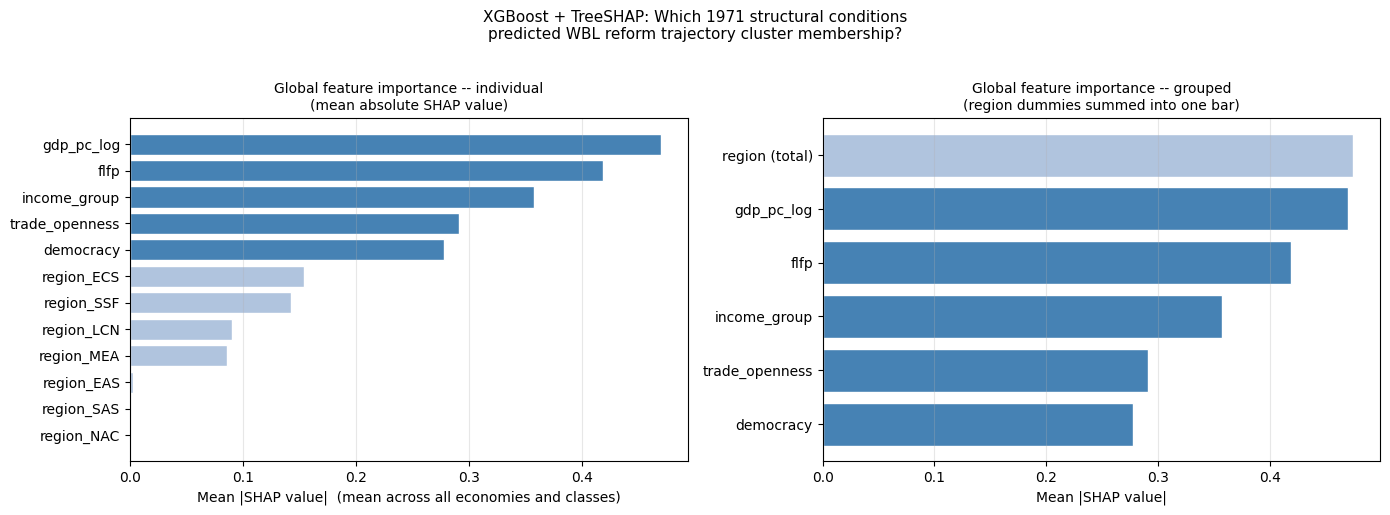

Saved: /content/drive/MyDrive/wbl_project/outputs/figures/shap_global_importance.png

=== TOP FEATURES BY MEAN |SHAP| ===
       feature  mean_abs_shap
    gdp_pc_log       0.469742
          flfp       0.418629
  income_group       0.357561
trade_openness       0.291156
     democracy       0.277963
    region_ECS       0.153655
    region_SSF       0.142453
    region_LCN       0.089905
    region_MEA       0.085857
    region_EAS       0.002798
    region_SAS       0.000000
    region_NAC       0.000000


In [ ]:
#  Global feature importance: bar plot (mean |SHAP|)
#
# Mean absolute SHAP value per feature, averaged across all economies
# and all classes. This is the global importance ranking.
# "Which 1971 structural condition best predicts which reform trajectory
# a country followed?"
#
# Note on region columns: region is split into 7 binary dummies.
# We show individual region effects AND a grouped 'region (total)'
# computed as the sum of all region dummy importances.

# Mean |SHAP| per feature (average over classes and economies)
mean_abs_shap = np.mean([np.abs(sv) for sv in shap_values], axis=0)  # (189, n_features)
mean_abs_shap = mean_abs_shap.mean(axis=0)                             # (n_features,)

importance_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False)

# Compute grouped region importance
region_cols   = [c for c in FEATURE_NAMES if c.startswith('region_')]
region_total  = importance_df[importance_df['feature'].isin(region_cols)]['mean_abs_shap'].sum()
non_region    = importance_df[~importance_df['feature'].isin(region_cols)].copy()
region_row    = pd.DataFrame([{'feature': 'region (total)', 'mean_abs_shap': region_total}])
importance_grouped = pd.concat([non_region, region_row]).sort_values('mean_abs_shap', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: individual features
colors_left = ['steelblue' if not f.startswith('region_') else 'lightsteelblue'
               for f in importance_df['feature']]
axes[0].barh(importance_df['feature'][::-1], importance_df['mean_abs_shap'][::-1],
             color=colors_left[::-1], edgecolor='white')
axes[0].set_xlabel('Mean |SHAP value|  (mean across all economies and classes)')
axes[0].set_title('Global feature importance -- individual\n'
                  '(mean absolute SHAP value)', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Right: grouped (region collapsed)
colors_right = ['steelblue' if f != 'region (total)' else 'lightsteelblue'
                for f in importance_grouped['feature']]
axes[1].barh(importance_grouped['feature'][::-1], importance_grouped['mean_abs_shap'][::-1],
             color=colors_right[::-1], edgecolor='white')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Global feature importance -- grouped\n'
                  '(region dummies summed into one bar)', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('XGBoost + TreeSHAP: Which 1971 structural conditions\n'
             'predicted WBL reform trajectory cluster membership?',
             fontsize=11, y=1.02)
plt.tight_layout()
fig_path = f'{BASE}/outputs/figures/shap_global_importance.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")

print("\n=== TOP FEATURES BY MEAN |SHAP| ===")
print(importance_df.to_string(index=False))


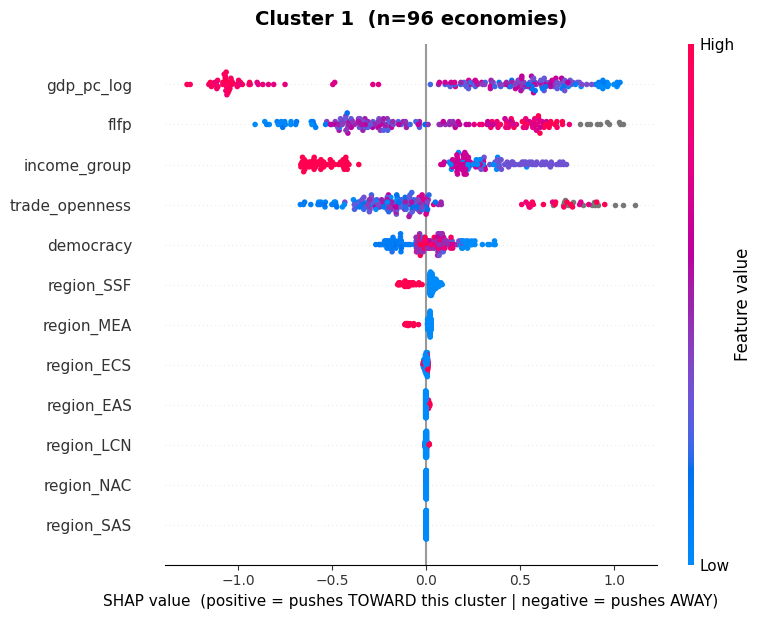

Saved Cluster 1: /content/drive/MyDrive/wbl_project/outputs/figures/shap_beeswarm_cluster1.png


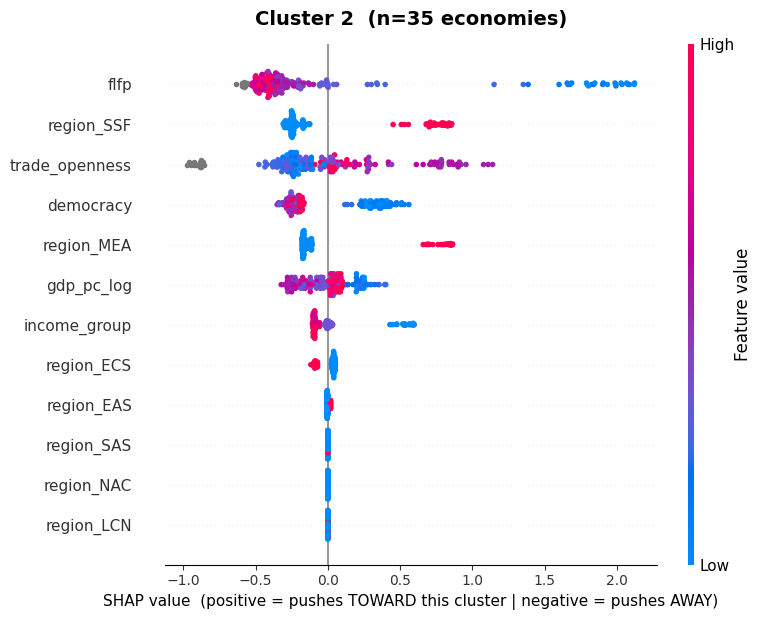

Saved Cluster 2: /content/drive/MyDrive/wbl_project/outputs/figures/shap_beeswarm_cluster2.png


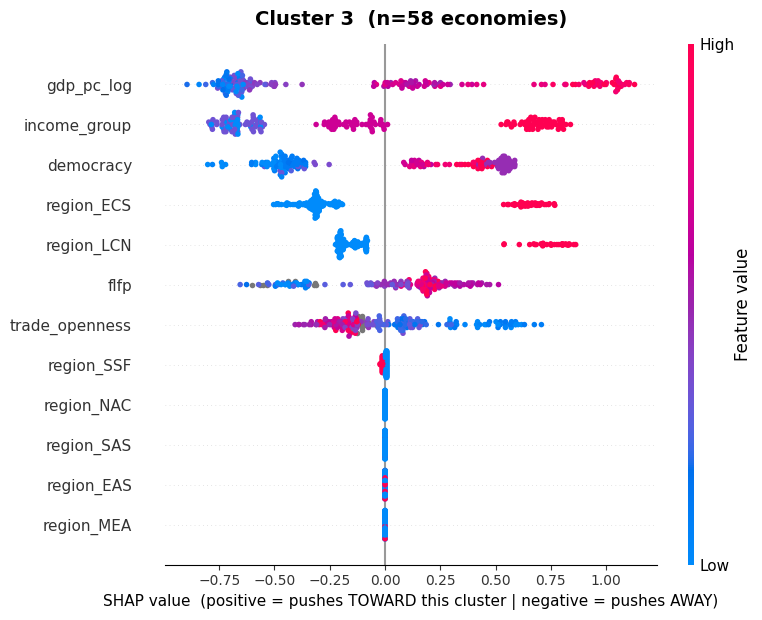

Saved Cluster 3: /content/drive/MyDrive/wbl_project/outputs/figures/shap_beeswarm_cluster3.png


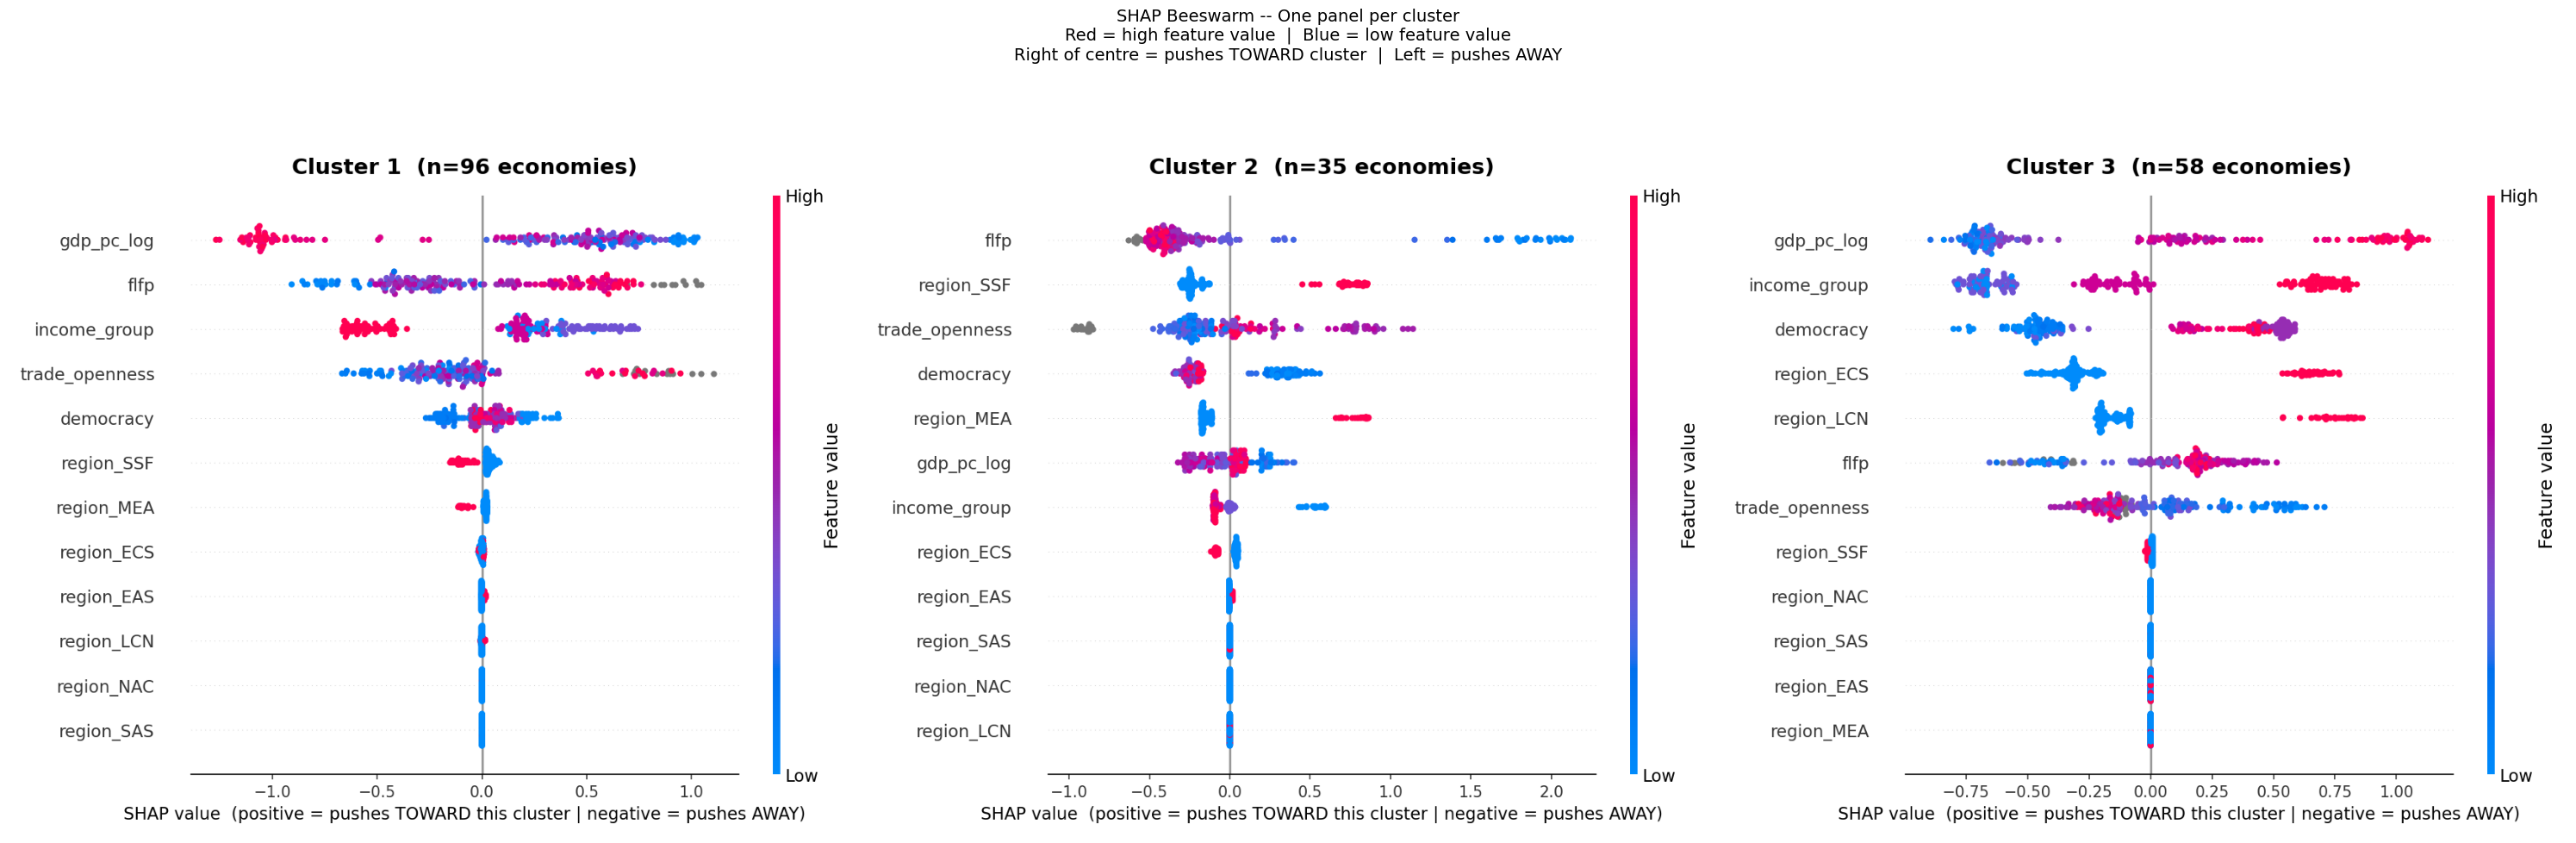


Combined beeswarm saved: /content/drive/MyDrive/wbl_project/outputs/figures/shap_beeswarm.png
Each cluster also saved individually (shap_beeswarm_cluster1.png etc.)
Use the individual files for the paper -- they are much more readable.


In [ ]:
# Plotting SHAP Beeswarm: one large figure per cluster
#
# shap.summary_plot(plot_type='dot') creates its own axes internally.
# The only reliable layout: one plt.figure() per cluster, let shap draw,
# then combine the saved PNGs into a single panel for the paper.
#
# Sizes: FIG_W=10, FIG_H scales with feature count so labels are readable.
# Each cluster saved individually first, then assembled into one image.



N_FEATURES = len(FEATURE_NAMES)
FIG_H  = max(8, 0.6 * N_FEATURES + 3)
FIG_W  = 10

individual_paths = []

for c in range(N_CLASSES):
    fig = plt.figure(figsize=(FIG_W, FIG_H))

    shap.summary_plot(
        shap_values[c],
        X_float,
        feature_names   = FEATURE_NAMES,
        plot_type       = 'dot',
        show            = False,
        max_display     = N_FEATURES,
        color_bar_label = 'Feature value',
    )

    # shap creates its own axes -- access via gcf/gca
    ax = plt.gca()
    ax.set_title(f'Cluster {c+1}  (n={(y==c).sum()} economies)', fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel('SHAP value  (positive = pushes TOWARD this cluster | negative = pushes AWAY)', fontsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.tick_params(axis='x', labelsize=10)

    plt.tight_layout()
    p = f'{BASE}/outputs/figures/shap_beeswarm_cluster{c+1}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    individual_paths.append(p)
    print(f"Saved Cluster {c+1}: {p}")

# Combine into one wide multi-panel figure
imgs = [mpimg.imread(p) for p in individual_paths]
n_cols = min(N_CLASSES, 3)
n_rows = (N_CLASSES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(FIG_W * n_cols, FIG_H * n_rows), squeeze=False)

for i, img in enumerate(imgs):
    r, col = divmod(i, n_cols)
    axes[r][col].imshow(img)
    axes[r][col].axis('off')

for i in range(N_CLASSES, n_rows * n_cols):
    r, col = divmod(i, n_cols)
    axes[r][col].axis('off')

plt.suptitle('SHAP Beeswarm -- One panel per cluster\n'
    'Red = high feature value  |  Blue = low feature value\n'
    'Right of centre = pushes TOWARD cluster  |  Left = pushes AWAY',
    fontsize=14, y=1.01
)
plt.tight_layout()
combined = f'{BASE}/outputs/figures/shap_beeswarm.png'
plt.savefig(combined, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"Combined beeswarm saved: {combined}")


=== HIGHEST-CONFIDENCE ECONOMY PER CLUSTER ===
  Cluster 1: MMR  (confidence = 0.990)
  Cluster 2: SAU  (confidence = 0.957)
  Cluster 3: CZE  (confidence = 0.985)

Baseline (E[f(X)]) per class:
  Cluster 1: 0.2916
  Cluster 2: -0.0151
  Cluster 3: -0.0479


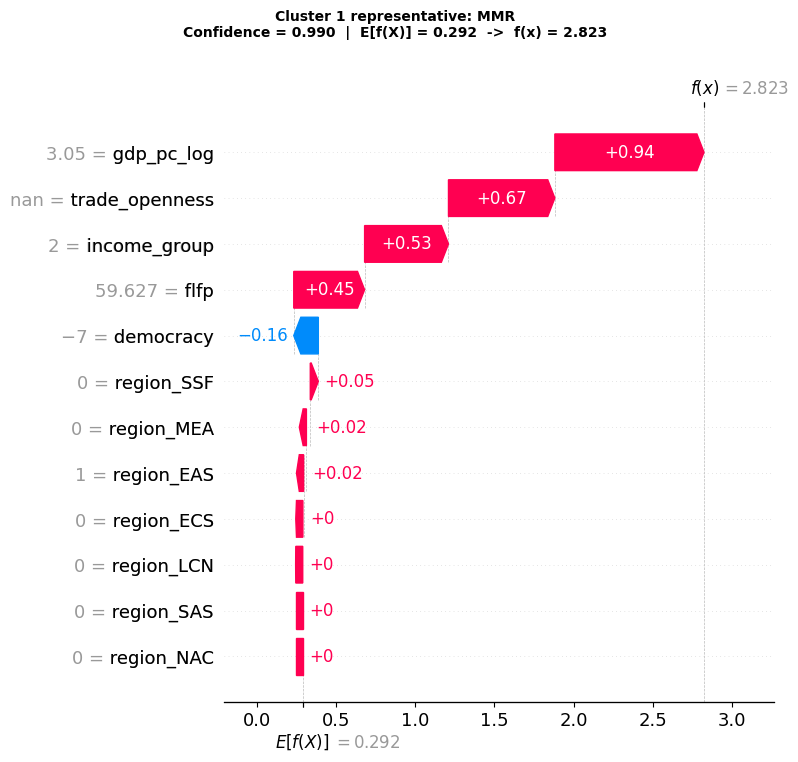

Saved: /content/drive/MyDrive/wbl_project/outputs/figures/shap_waterfall_cluster1.png


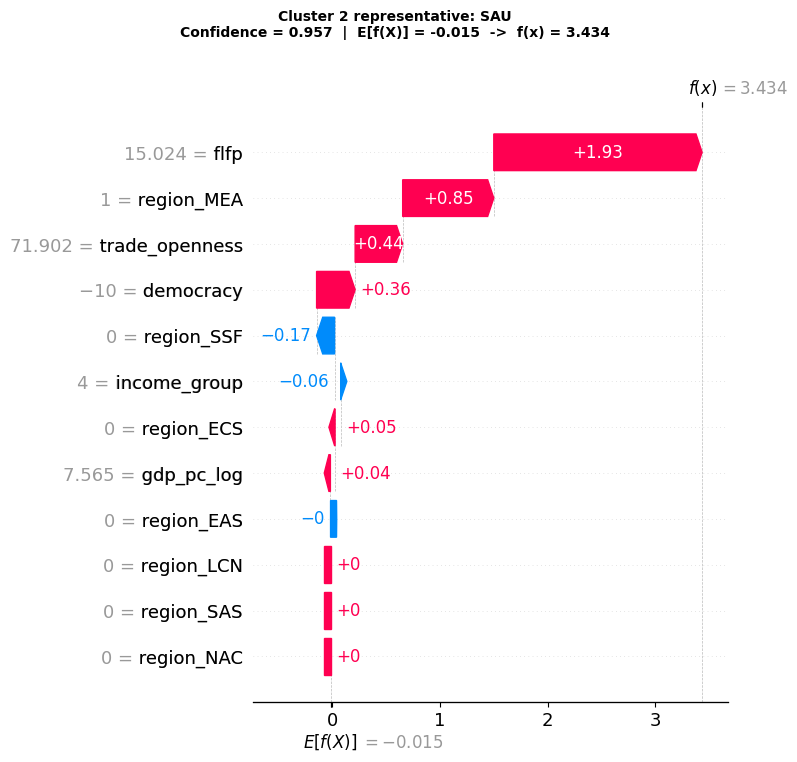

Saved: /content/drive/MyDrive/wbl_project/outputs/figures/shap_waterfall_cluster2.png


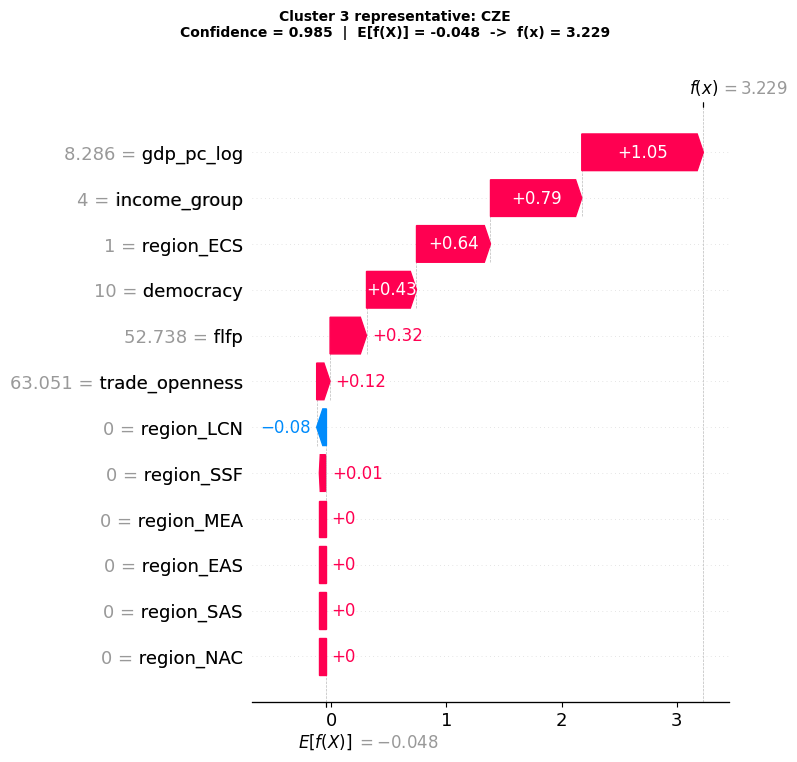

Saved: /content/drive/MyDrive/wbl_project/outputs/figures/shap_waterfall_cluster3.png


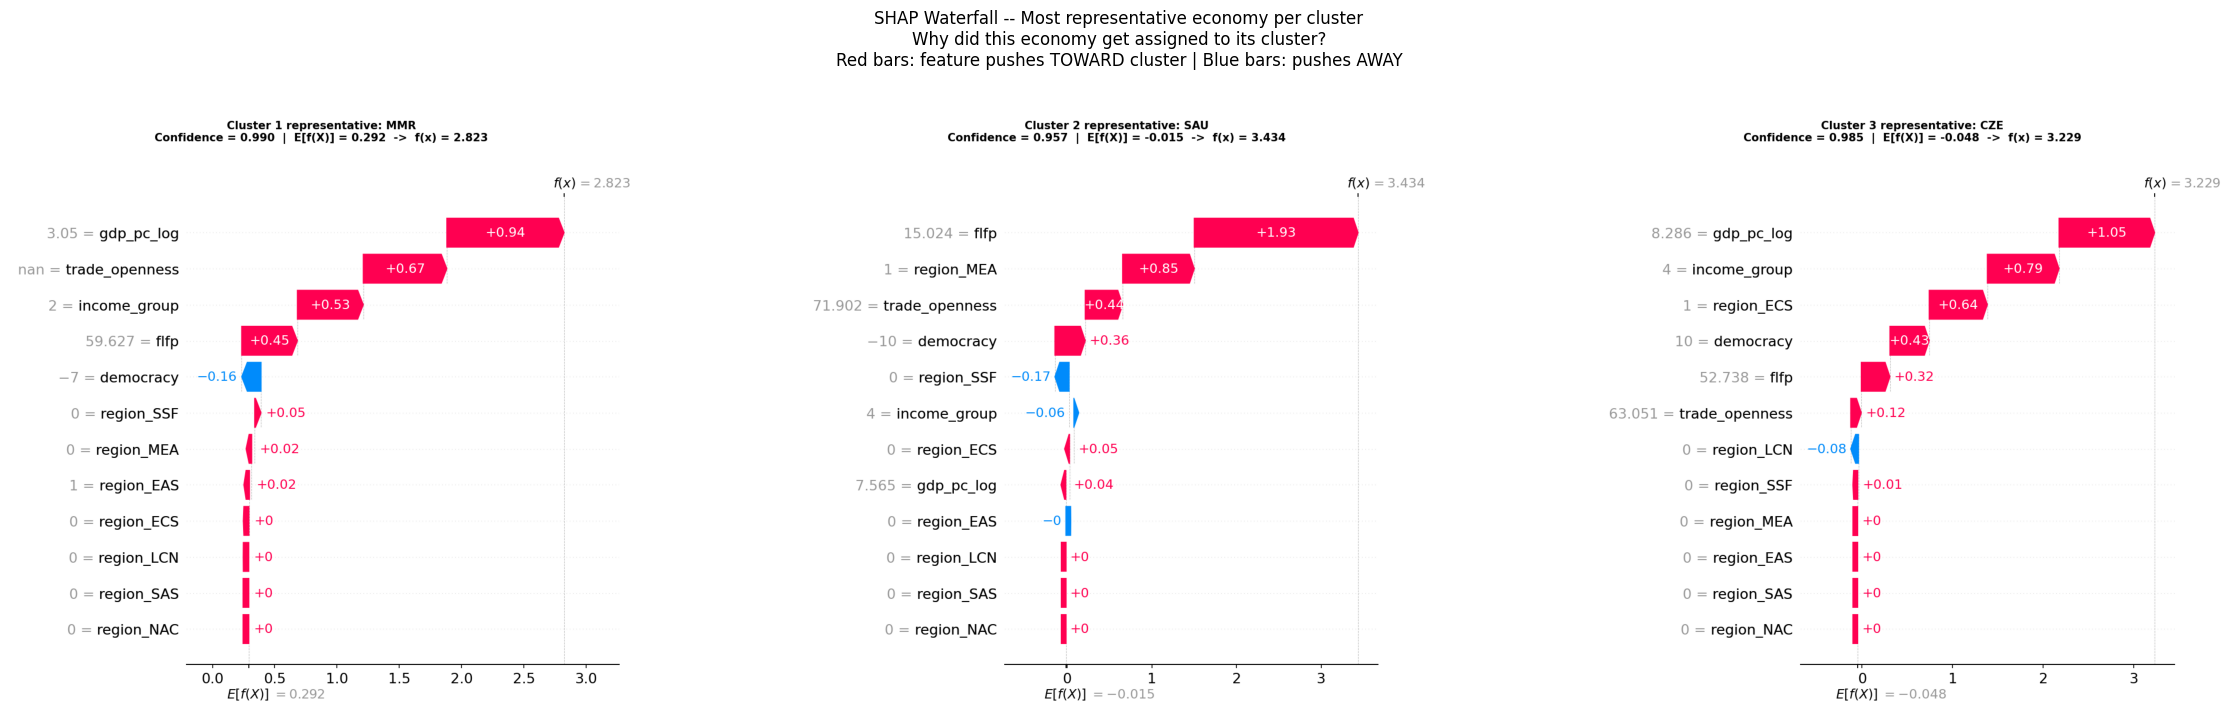


Combined waterfall saved: /content/drive/MyDrive/wbl_project/outputs/figures/shap_waterfall_medoids.png


In [ ]:
# Plot features to describe each cluster
#
# A waterfall plot explains ONE economy prediction feature by feature.
#   E[f(X)]  = baseline (average model output across all 189 economies)
#   f(x_i)   = the model's prediction for this specific economy
#   Red bars  = positive SHAP -- feature pushes TOWARD this cluster
#   Blue bars = negative SHAP -- feature pushes AWAY
#
# Local Accuracy (Lundberg & Lee 2017):
#   f(x_i) = E[f(X)] + sum_j phi_j(i)
#   The bars sum EXACTLY to the gap between baseline and prediction.
#


import matplotlib.image as mpimg

print("=== HIGHEST-CONFIDENCE ECONOMY PER CLUSTER ===")
proba = clf_final.predict_proba(X_float)   # shape: (189, k)

medoid_economies = []
for c in range(N_CLASSES):
    mask = (y == c)
    if mask.sum() == 0:
        continue
    proba_c = proba[mask, c]
    best_i  = np.where(mask)[0][np.argmax(proba_c)]
    eco     = ECONOMIES[best_i]
    conf    = float(proba_c.max())
    medoid_economies.append((c, best_i, eco, conf))
    print(f"  Cluster {c+1}: {eco}  (confidence = {conf:.3f})")

# ── Extract baseline expected values: one SCALAR per class ────────────────
# For multi-class XGBoost, explainer.expected_value is a numpy array.
# We must index into it and cast to plain Python float before passing
# to shap.Explanation -- otherwise waterfall_plot raises TypeError.
ev = explainer.expected_value
if hasattr(ev, '__len__') and len(ev) > 1:
    # Multi-class: [v_0, v_1, ..., v_{k-1}]
    base_by_class = [float(ev[c]) for c in range(N_CLASSES)]
elif hasattr(ev, '__len__') and len(ev) == 1:
    base_by_class = [float(ev[0])] * N_CLASSES
else:
    base_by_class = [float(ev)] * N_CLASSES

print()
print("Baseline (E[f(X)]) per class:")
for c, bv in enumerate(base_by_class):
    print(f"  Cluster {c+1}: {bv:.4f}")

# ── Plot one waterfall per cluster representative ─────────────────────────
waterfall_paths = []
N_FEATURES = len(FEATURE_NAMES)

for c, idx, eco, conf in medoid_economies:

    # Build the Explanation object with a guaranteed scalar base_value
    exp = shap.Explanation(
        values        = shap_values[c][idx],       # 1D float array (p,)
        base_values   = base_by_class[c],           # plain Python float
        data          = X_float.iloc[idx].values,  # 1D float array (p,)
        feature_names = FEATURE_NAMES,
    )

    # waterfall_plot always creates its own figure -- do not pre-create axes
    shap.waterfall_plot(exp, max_display=N_FEATURES, show=False)

    fig = plt.gcf()
    fig.suptitle(
        f"Cluster {c+1} representative: {eco}\n"
        f"Confidence = {conf:.3f}  |  "
        f"E[f(X)] = {base_by_class[c]:.3f}  ->  f(x) = {base_by_class[c] + shap_values[c][idx].sum():.3f}",
        fontsize=10, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    p = f'{BASE}/outputs/figures/shap_waterfall_cluster{c+1}.png'
    plt.savefig(p, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    waterfall_paths.append(p)
    print(f"Saved: {p}")

# Combine into one panel
imgs  = [mpimg.imread(p) for p in waterfall_paths]
n_med = len(imgs)
fig, axes = plt.subplots(1, n_med, figsize=(8 * n_med, 7), squeeze=False)
for i, img in enumerate(imgs):
    axes[0][i].imshow(img)
    axes[0][i].axis('off')

plt.suptitle(
    'SHAP Waterfall -- Most representative economy per cluster\n'
    'Why did this economy get assigned to its cluster?\n'
    'Red bars: feature pushes TOWARD cluster | Blue bars: pushes AWAY',
    fontsize=12, y=1.02
)
plt.tight_layout()

# save the combined plot
combined = f'{BASE}/outputs/figures/shap_waterfall_medoids.png'
plt.savefig(combined, dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print(f"\nCombined waterfall saved: {combined}")


In [ ]:
# Sensitivity check: economies with ALL features at exact 1971
#
# Some economies use fallback years for some features (e.g. FLFP
# at 1988 instead of 1971). This check re-runs the full XGBoost +
# SHAP pipeline on only the subset of economies that have all
# continuous features observed at exactly 1971.
#
# If the SHAP feature ranking is stable (same top 3, similar magnitudes),
# the fallback year approach is validated.
# Reference: project methodology document, DD-005 sensitivity check;
# Hyland, Djankov & Goldberg (2020) use the same approach.

baseline_path = f'{BASE}/data/external/baseline_years_used.csv'

if not os.path.exists(baseline_path):
    print("baseline_years_used.csv not found.")
    print("Skipping sensitivity check -- run feature_engineering.ipynb first.")
else:
    baseline = pd.read_csv(baseline_path, index_col=0)
    print(f"Baseline years file shape: {baseline.shape}")
    print(f"Columns: {baseline.columns.tolist()}")

    # Find economies with all continuous features at exactly 1971
    year_cols = [c for c in baseline.columns if c.endswith('_year')]
    exact_1971_mask = (baseline[year_cols] == 1971).all(axis=1)
    exact_economies = baseline[exact_1971_mask].index.tolist()

    print(f"\nEconomies with ALL features at exact 1971: {len(exact_economies)}")
    print("(A smaller subset -- expected, since FLFP coverage was near-zero at 1971)")

    if len(exact_economies) >= 30:
        # Re-run XGBoost on this subset
        mask_exact   = [e in exact_economies for e in ECONOMIES]
        X_exact      = X[mask_exact].astype(float)
        y_exact      = y[mask_exact]

        if len(np.unique(y_exact)) < 2:
            print("Only one class in exact-1971 subset -- sensitivity check not feasible.")
        else:
            clf_sens = xgb.XGBClassifier(**model_params)
            sw_exact = compute_sample_weight('balanced', y_exact) if USE_WEIGHTS else None
            clf_sens.fit(X_exact, y_exact,
                         sample_weight=sw_exact if sw_exact is not None else None)

            exp_sens = shap.TreeExplainer(clf_sens, data=X_exact.astype(float),
                                           feature_perturbation='tree_path_dependent')
            sv_sens = exp_sens.shap_values(X_exact.astype(float))
            if isinstance(sv_sens, np.ndarray) and sv_sens.ndim == 3:
                sv_sens = [sv_sens[:,:,c] for c in range(N_CLASSES)]

            mean_abs_sens = np.mean([np.abs(sv) for sv in sv_sens], axis=0).mean(axis=0)
            imp_sens = pd.DataFrame({'feature': FEATURE_NAMES,
                                     'sens_shap': mean_abs_sens}).sort_values(
                                         'sens_shap', ascending=False)

            # Compare rankings
            print("\n=== FEATURE RANKING COMPARISON ===")
            print(f"{'Feature':<25} {'Full (189)':>12} {'Exact-1971':>12}")
            print("-" * 50)
            full_rank = {f: i for i, f in enumerate(importance_df['feature'])}
            sens_rank = {f: i for i, f in enumerate(imp_sens['feature'])}
            for f in importance_df['feature']:
                print(f"{f:<25} {full_rank[f]+1:>12}     {sens_rank.get(f,'-'):>10}")

            top3_full = importance_df['feature'].iloc[:3].tolist()
            top3_sens = imp_sens['feature'].iloc[:3].tolist()
            overlap   = len(set(top3_full) & set(top3_sens))
            print(f"\nTop-3 overlap: {overlap}/3 features match")
            if overlap >= 2:
                print("ROBUST: Feature ranking is stable to fallback year restriction.")
            else:
                print("SENSITIVE: Feature ranking changes substantially in exact-1971 subset.")
                print("Note this in DD-012 and discuss in the paper's limitations section.")
    else:
        print(f"Only {len(exact_economies)} economies at exact 1971 -- too few for robust re-run.")
        print("Sensitivity check not feasible. Note in DD-012.")


Baseline years file shape: (189, 3)
Columns: ['gdp_pc_year', 'flfp_year', 'trade_openness_year']

Economies with ALL features at exact 1971: 0
(A smaller subset -- expected, since FLFP coverage was near-zero at 1971)
Only 0 economies at exact 1971 -- too few for robust re-run.
Sensitivity check not feasible. Note in DD-012.


In [ ]:
# Cell 14 -- Anti-leakage verification and record DD-012 to DD-014

# ── Anti-leakage verification ────────────────────────────────────────────
print("=== ANTI-LEAKAGE VERIFICATION (DD-014) ===")
print("Features used in X (Matrix B):")
for col in X.columns:
    print(f"  {col}")

wbl_keywords = ['mobility','workplace','pay','marriage','parenthood',
                'entrepreneur','asset','pension','wbl','sg.law']
leak = [c for c in X.columns if any(k in c.lower() for k in wbl_keywords)]
if leak:
    print(f"\nLEAKAGE DETECTED: {leak}")
else:
    print("\nAnti-leakage CONFIRMED: no WBL sub-index in feature matrix.")

# ── Record DD entries ──────────────────────────────────────────────────
dd_path = f'{BASE}/reports/DESIGN_DECISIONS.md'

top3_str = ', '.join(importance_df['feature'].iloc[:3].tolist())

entry_lines = [
    "",
    "---",
    "",
    "## DD-012 -- XGBoost Class Balance",
    "",
    f"**Class distribution:** {dict(zip([f'Cluster {c+1}' for c in range(N_CLASSES)], [(y==c).sum() for c in range(N_CLASSES)]))}",
    f"**Smallest class:** {min((y==c).sum() for c in range(N_CLASSES))} economies  ({min_class_pct:.1f}%)",
    f"**sample_weight applied:** {USE_WEIGHTS}",
    f"**Dummy classifier macro-F1:** {dummy_f1:.4f}",
    f"**XGBoost CV macro-F1:** {cv_macro_f1:.4f}  (gain over dummy: {cv_macro_f1-dummy_f1:+.4f})",
    "**Source:** Chen & Guestrin (2016); project methodology document Section 5.",
    "",
    "---",
    "",
    "## DD-013 -- XGBoost Hyperparameters",
    "",
    "**Algorithm:** XGBoost gradient boosted trees (XGBClassifier).",
    f"**n_estimators:** 200  |  **max_depth:** 4  |  **learning_rate:** 0.05",
    f"**subsample:** 0.8  |  **colsample_bytree:** 0.8  |  **min_child_weight:** 5",
    f"**reg_alpha:** 0.1  |  **reg_lambda:** 1.0  |  **objective:** {objective}",
    "**Validation:** Stratified 5-fold cross-validation.",
    f"**CV macro-F1:** {cv_macro_f1:.4f}  |  **CV accuracy:** {cv_df['test_accuracy'].mean():.4f}",
    "**Source:** Chen & Guestrin (2016, KDD, pp. 785-794).",
    "",
    "---",
    "",
    "## DD-014 -- SHAP Results Summary",
    "",
    "**Method:** TreeSHAP (exact, polynomial-time computation).",
    "**Source:** Lundberg & Lee (2017, NeurIPS); Molnar (2025, Ch. 9).",
    f"**Top 3 features by mean |SHAP|:** {top3_str}",
    "**Anti-leakage:** confirmed -- no WBL sub-index in feature matrix.",
    "**Sensitivity check:** [FILL -- stable / sensitive, ARI of feature rankings]",
    "**Causal interpretation note:** SHAP values show statistical association,",
    "  not causation. Language: 'X is strongly associated with cluster membership'",
    "  not 'X caused the reform trajectory'. Per Al-Marhubi (2026) Section 2.2.",
    "",
    "---",
    "",
]

with open(dd_path, 'a') as f:
    f.write("\n".join(entry_lines) + "\n")

print("\nDD-012, DD-013, DD-014 appended to DESIGN_DECISIONS.md")
print()
print("=" * 60)
print("  DAY 4 COMPLETE. Next steps:")
print("=" * 60)
print()
print("  1. Fill [FILL] in DD-014 (sensitivity check result)")
print("  2. Fill the [FILL] interpretation text in DESIGN_DECISIONS.md:")
print("     For each top feature: what does a high value mean?")
print("     Which cluster does it push toward, and why does that make")
print("     economic sense given Al-Marhubi (2026) Section 2.2?")
print()
print("  3. Build validation.ipynb (world map, ARI vs Al-Marhubi clubs)")
print()
print("  Output files:")
print(f"    {BASE}/models/xgb_cluster_classifier.json")
print(f"    {BASE}/data/processed/shap_values.csv")
print(f"    {BASE}/data/processed/cv_results.csv")
print(f"    {BASE}/outputs/figures/shap_global_importance.png")
print(f"    {BASE}/outputs/figures/shap_beeswarm.png")
print(f"    {BASE}/outputs/figures/shap_dependence_top3.png")
print(f"    {BASE}/outputs/figures/shap_waterfall_medoids.png")
print(f"    {BASE}/outputs/figures/confusion_matrix.png")
print(f"    {BASE}/outputs/figures/feature_correlation.png")


=== ANTI-LEAKAGE VERIFICATION (DD-014) ===
Features used in X (Matrix B):
  gdp_pc_log
  flfp
  trade_openness
  income_group
  region_EAS
  region_ECS
  region_LCN
  region_MEA
  region_NAC
  region_SAS
  region_SSF
  democracy

Anti-leakage CONFIRMED: no WBL sub-index in feature matrix.

DD-012, DD-013, DD-014 appended to DESIGN_DECISIONS.md

  DAY 4 COMPLETE. Next steps:

  1. Fill [FILL] in DD-014 (sensitivity check result)
  2. Fill the [FILL] interpretation text in DESIGN_DECISIONS.md:
     For each top feature: what does a high value mean?
     Which cluster does it push toward, and why does that make
     economic sense given Al-Marhubi (2026) Section 2.2?

  3. Build validation.ipynb (world map, ARI vs Al-Marhubi clubs)

  Output files:
    /content/drive/MyDrive/wbl_project/models/xgb_cluster_classifier.json
    /content/drive/MyDrive/wbl_project/data/processed/shap_values.csv
    /content/drive/MyDrive/wbl_project/data/processed/cv_results.csv
    /content/drive/MyDrive/wbl_